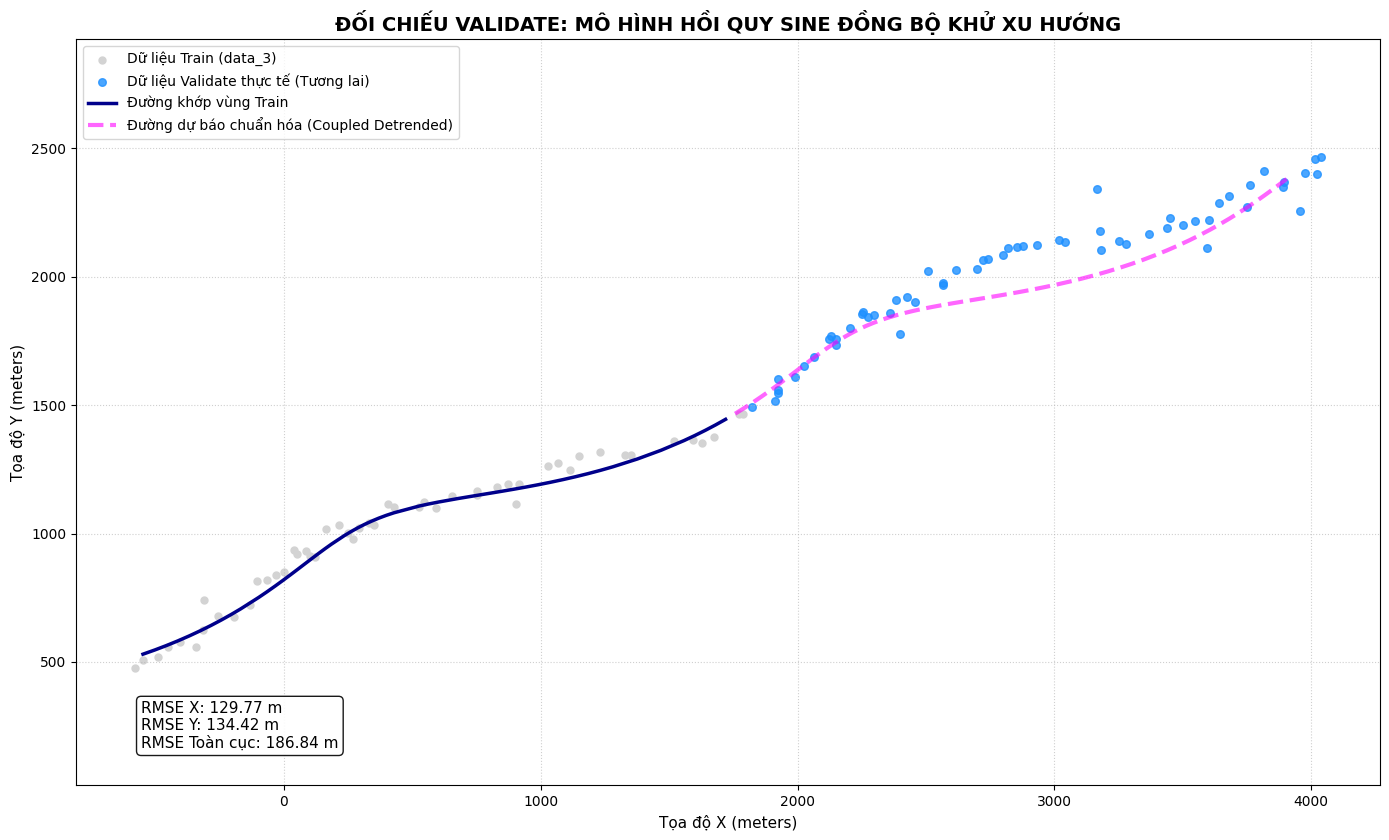

--> RMSE Toàn cục mới: 186.84 mét (Giảm mạnh so với mô hình cũ!)


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# ==============================================================================
# BƯỚC 1: ĐỌC VÀ CHUẨN HÓA TOÀN BỘ DỮ LIỆU
# ==============================================================================
df_train = pd.read_csv("data_3.csv").sort_values("time_s").reset_index(drop=True)
df_val = (
    pd.read_csv("data_3_after_and_before_t0.csv")
    .sort_values("time_s")
    .reset_index(drop=True)
)

for data in [df_train, df_val]:
    data["theta_rad"] = np.radians(data["bearing_deg"])
    data["x"] = data["range_m"] * np.cos(data["theta_rad"])
    data["y"] = data["range_m"] * np.sin(data["theta_rad"])


# Lọc nhiễu Hampel cho tập Train
def hampel_filter(series, window_size=5, n_sigmas=2.0):
    rolling_median = series.rolling(window=window_size, center=True).median()
    mad = series.rolling(window=window_size, center=True).apply(
        lambda x: np.median(np.abs(x - np.median(x))), raw=True
    )
    return (np.abs(series - rolling_median) > (n_sigmas * 1.4826 * mad)).fillna(
        False
    )


df_train_clean = df_train[
    ~(hampel_filter(df_train["x"]) | hampel_filter(df_train["y"]))
].copy()

t_train = df_train_clean["time_s"].values
x_train = df_train_clean["x"].values
y_train = df_train_clean["y"].values

# ==============================================================================
# BƯỚC 2: TÁCH BIỆT XU HƯỚNG TUYẾN TÍNH (DETRENDING)
# ==============================================================================
# Khóa chặt vận tốc nền để đảm bảo extrapolation an toàn
vx, x0 = np.polyfit(t_train, x_train, 1)
vy, y0 = np.polyfit(t_train, y_train, 1)

# Trích xuất phần dư (Chỉ còn lại sóng dao động thuần túy quanh trục 0)
x_res = x_train - (vx * t_train + x0)
y_res = y_train - (vy * t_train + y0)


# ==============================================================================
# BƯỚC 3: KHỚP SÓNG SINE ĐỒNG THỜI VỚI TẦN SỐ RÀNG BUỘC (COUPLED SINE FIT)
# ==============================================================================
# Hàm mục tiêu gộp cả X và Y để ép dùng chung tần số omega
def joint_sine_model(t_combined, A_x, phi_x, A_y, phi_y, omega):
    N = len(t_combined) // 2
    t_x = t_combined[:N]
    t_y = t_combined[N:]
    return np.concatenate(
        [A_x * np.sin(omega * t_x + phi_x), A_y * np.sin(omega * t_y + phi_y)]
    )


t_combined = np.concatenate([t_train, t_train])
res_combined = np.concatenate([x_res, y_res])

# Ràng buộc chặt chẽ để omega không thể triệt tiêu về 0 (Ép tạo sóng chu kỳ từ ~20s đến ~120s)
lower_bounds = [0, -np.pi, 0, -np.pi, 0.05]
upper_bounds = [300, np.pi, 300, np.pi, 0.30]

popt_joint, _ = curve_fit(
    joint_sine_model,
    t_combined,
    res_combined,
    p0=[100, 0, 100, 0, 0.1],
    bounds=(lower_bounds, upper_bounds),
    maxfev=20000,
)
A_x, phi_x, A_y, phi_y, omega_shared = popt_joint

# ==============================================================================
# BƯỚC 4: DỰ BÁO TƯƠNG LAI VÀ VALIDATE KẾT QUẢ
# ==============================================================================
# Chỉ lấy các mốc thời gian thực sự nằm trong tương lai để kiểm thử khả năng dự báo
df_future_val = df_val[df_val["time_s"] > t_train.max()].copy()
t_val = df_future_val["time_s"].values

# Thực hiện dự báo kết hợp: Xu hướng tuyến tính vững chắc + Sóng điều hòa chuẩn pha
x_val_pred = (vx * t_val + x0) + A_x * np.sin(omega_shared * t_val + phi_x)
y_val_pred = (vy * t_val + y0) + A_y * np.sin(omega_shared * t_val + phi_y)

# Tính toán các chỉ số RMSE thực tế trên tập Validate
rmse_x = np.sqrt(np.mean((df_future_val["x"].values - x_val_pred) ** 2))
rmse_y = np.sqrt(np.mean((df_future_val["y"].values - y_val_pred) ** 2))
rmse_total = np.sqrt(
    np.mean(
        (df_future_val["x"].values - x_val_pred) ** 2
        + (df_future_val["y"].values - y_val_pred) ** 2
    )
)

# ==============================================================================
# BƯỚC 5: TRỰC QUAN HÓA ĐỒ THỊ
# ==============================================================================
plt.figure(figsize=(14, 8.5))

plt.scatter(
    df_train_clean["x"],
    df_train_clean["y"],
    color="lightgray",
    s=25,
    label="Dữ liệu Train (data_3)",
)
plt.scatter(
    df_future_val["x"],
    df_future_val["y"],
    color="dodgerblue",
    s=30,
    alpha=0.8,
    label="Dữ liệu Validate thực tế (Tương lai)",
)

# Vẽ đường mô hình khớp trong vùng Train
x_fit_past = (vx * t_train + x0) + A_x * np.sin(omega_shared * t_train + phi_x)
y_fit_past = (vy * t_train + y0) + A_y * np.sin(omega_shared * t_train + phi_y)
plt.plot(
    x_fit_past, y_fit_past, color="darkblue", linewidth=2.5, label="Đường khớp vùng Train"
)

# Đường dự báo chuẩn hóa (Nét đứt mờ)
plt.plot(
    x_val_pred,
    y_val_pred,
    color="magenta",
    linestyle="--",
    linewidth=3,
    alpha=0.6,
    label="Đường dự báo chuẩn hóa (Coupled Detrended)",
)

# Hiển thị bảng chỉ số RMSE mới lên đồ thị
info_box = f"RMSE X: {rmse_x:.2f} m\nRMSE Y: {rmse_y:.2f} m\nRMSE Toàn cục: {rmse_total:.2f} m"
plt.gca().text(
    0.05,
    0.05,
    info_box,
    transform=plt.gca().transAxes,
    fontsize=11,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9),
)

plt.title(
    "ĐỐI CHIẾU VALIDATE: MÔ HÌNH HỒI QUY SINE ĐỒNG BỘ KHỬ XU HƯỚNG",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Tọa độ X (meters)", fontsize=11)
plt.ylabel("Tọa độ Y (meters)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left", fontsize=10)
plt.axis("equal")
plt.tight_layout()
plt.show()

print(f"--> RMSE Toàn cục mới: {rmse_total:.2f} mét (Giảm mạnh so với mô hình cũ!)")

In [7]:
# ==============================================================================
# TÍNH VÀ IN RA ABSOLUTE ERROR (AE) TẠI MỐC 5s, 10s, 20s
# ==============================================================================
print(f"\n{'--- BÁO CÁO SAI SỐ TUYỆT ĐỐI (ABSOLUTE ERROR) ---':^50}")
print(f"{'Mốc (s)':<10} | {'AE X (m)':<12} | {'AE Y (m)':<12} | {'AE Tổng (m)':<12}")
print("-" * 55)

for offset in [5, 10, 20]:
    t_target = t_train.max() + offset
    
    # Tìm dữ liệu thực tế gần nhất với mốc thời gian dự báo
    idx = (df_future_val['time_s'] - t_target).abs().idxmin()
    actual_row = df_future_val.loc[idx]
    
    # Tính dự báo tại mốc t_target
    pred_x = (vx * t_target + x0) + A_x * np.sin(omega_shared * t_target + phi_x)
    pred_y = (vy * t_target + y0) + A_y * np.sin(omega_shared * t_target + phi_y)
    
    # Tính Absolute Error
    ae_x = abs(actual_row['x'] - pred_x)
    ae_y = abs(actual_row['y'] - pred_y)
    ae_total = np.sqrt(ae_x**2 + ae_y**2)
    
    print(f"+{offset:<8} | {ae_x:<12.2f} | {ae_y:<12.2f} | {ae_total:<12.2f}")

print("-" * 55)


--- BÁO CÁO SAI SỐ TUYỆT ĐỐI (ABSOLUTE ERROR) --- 
Mốc (s)    | AE X (m)     | AE Y (m)     | AE Tổng (m) 
-------------------------------------------------------
+5        | 32.04        | 3.07         | 32.19       
+10       | 88.10        | 94.09        | 128.90      
+20       | 132.10       | 102.75       | 167.36      
-------------------------------------------------------
